In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
path_data = os.getcwd() + '/data/'
path_demand = path_data + 'output/csv/demand/'
path_loads =path_data + 'loads/'
path_generation = path_data + 'generators_profiles/'
path_losses = path_data + 'output/csv/losses/'
path_bess = path_data + 'output/csv/bess/'

In [12]:
file_loads = path_loads + 'total_loads.csv'
file_generation = path_generation + 'total_generation.csv'
file_losses = path_losses + 'Losses_NoOperation_year_CondominioDosIpes.csv'
file_demand = path_demand + 'Demand_NoOperation_year_CondominioDosIpes.csv'
file_demand_forecasting = path_demand + 'Demand_Smoothing_bus013_year_CondominioDosIpes.csv'
bess_forecasting = path_bess + 'BessPowers_Forecasting_bus013_year_CondominioDosIpes.csv'

In [13]:
data_loads = pd.read_csv(file_loads)
data_loads['datetime'] = pd.to_datetime(data_loads['datetime'])
data_generation = pd.read_csv(file_generation)
data_generation['datetime'] = pd.to_datetime(data_generation['datetime'])
data_losses = pd.read_csv(file_losses)
data_losses['Timestep'] = pd.to_datetime(data_losses['Timestep'])
data_demand = pd.read_csv(file_demand)
data_demand['Timestep'] = pd.to_datetime(data_demand['Timestep'])
data_demand_forecasting = pd.read_csv(file_demand_forecasting)
data_demand_forecasting['Timestep'] = pd.to_datetime(data_demand_forecasting['Timestep'])
data_bess_forecasting = pd.read_csv(bess_forecasting)
data_bess_forecasting['Timestep'] = pd.to_datetime(data_bess_forecasting['Timestep'])
date_ini = pd.Timestamp('2012-07-07 05:30:00')
date_end = pd.Timestamp('2012-07-09 05:30:00')

In [14]:
demand_manual = pd.DataFrame(columns=['datetime', 'Ppower'])  
# Calculate Ppower manually = load + losses - generation between date_ini and date_end
for timestep in pd.date_range(date_ini, date_end, freq='5min'):
    load = data_loads[data_loads['datetime'] == timestep]['Ppower'].values[0]
    generation = data_generation[data_generation['datetime'] == timestep]['Ppower'].values[0]
    losses = data_losses[data_losses['Timestep'] == timestep]['P(kW)'].values[0]
    demand = load + losses - generation
    demand_manual = pd.concat([demand_manual, pd.DataFrame({'datetime': [timestep], 'Ppower': [demand]})], ignore_index=True)
demand_manual['datetime'] = pd.to_datetime(demand_manual['datetime'])
demand_manual.head()

C:\Users\joao9\AppData\Local\Temp\ipykernel_10024\3855719874.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  demand_manual = pd.concat([demand_manual, pd.DataFrame({'datetime': [timestep], 'Ppower': [demand]})], ignore_index=True)


,datetime,Ppower
0,2012-07-07 05:30:00,2.185306
1,2012-07-07 05:35:00,2.266840
2,2012-07-07 05:40:00,2.348373
3,2012-07-07 05:45:00,2.429907
4,2012-07-07 05:50:00,2.511441


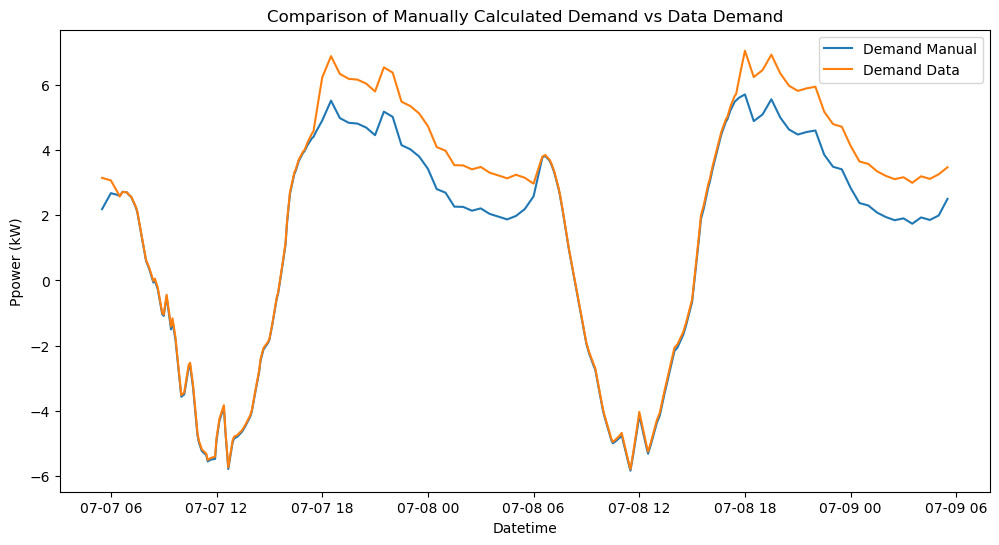

In [15]:
# Plot demand_manual vs data_demand between date_ini and date_end
plt.figure(figsize=(12,6))
plt.plot(demand_manual['datetime'], demand_manual['Ppower'], label='Demand Manual')
plt.plot(data_demand[(data_demand['Timestep'] >= date_ini) & (data_demand['Timestep'] <= date_end)]['Timestep'], 
         data_demand[(data_demand['Timestep'] >= date_ini) & (data_demand['Timestep'] <= date_end)]['P(kW)'], label='Demand Data')
plt.xlabel('Datetime')
plt.ylabel('Ppower (kW)')
plt.title('Comparison of Manually Calculated Demand vs Data Demand')
plt.legend()


# Simulando a suavização na mão

In [16]:
demand_manual = pd.DataFrame(columns=['datetime', 'Ppower'])  
# Calculate Ppower manually = load + losses - generation between date_ini and date_end
for timestep in pd.date_range(date_ini, date_end, freq='5min'):
    load = data_loads[data_loads['datetime'] == timestep]['Ppower'].values[0]
    generation = data_generation[data_generation['datetime'] == timestep]['Ppower'].values[0]
    losses = data_losses[data_losses['Timestep'] == timestep]['P(kW)'].values[0]
    bess = data_bess_forecasting[data_bess_forecasting['Timestep'] == timestep]['P(kW)'].values[0]
    demand = load + losses - generation + bess
    demand_manual = pd.concat([demand_manual, pd.DataFrame({'datetime': [timestep], 'Ppower': [demand]})], ignore_index=True)
demand_manual['datetime'] = pd.to_datetime(demand_manual['datetime'])
demand_manual.head()

C:\Users\joao9\AppData\Local\Temp\ipykernel_10024\1130842585.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  demand_manual = pd.concat([demand_manual, pd.DataFrame({'datetime': [timestep], 'Ppower': [demand]})], ignore_index=True)


,datetime,Ppower
0,2012-07-07 05:30:00,2.185306
1,2012-07-07 05:35:00,2.266840
2,2012-07-07 05:40:00,2.348373
3,2012-07-07 05:45:00,-3.521393
4,2012-07-07 05:50:00,-4.791959


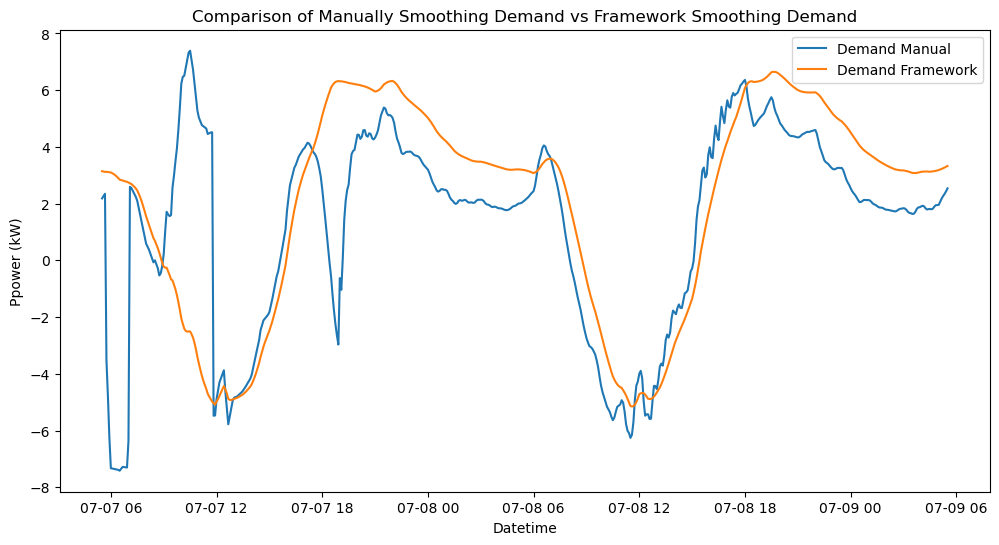

In [19]:
# Plot demand_manual vs data_demand between date_ini and date_end
plt.figure(figsize=(12,6))
plt.plot(demand_manual['datetime'], demand_manual['Ppower'], label='Demand Manual')
plt.plot(data_demand_forecasting[(data_demand_forecasting['Timestep'] >= date_ini) & (data_demand_forecasting['Timestep'] <= date_end)]['Timestep'], 
         data_demand_forecasting[(data_demand_forecasting['Timestep'] >= date_ini) & (data_demand_forecasting['Timestep'] <= date_end)]['P(kW)'], label='Demand Framework')
plt.xlabel('Datetime')
plt.ylabel('Ppower (kW)')
plt.title('Comparison of Manually Smoothing Demand vs Framework Smoothing Demand')
plt.legend()